In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, numpy as np, pandas as pd, ast, torch

BASE = "/content/drive/MyDrive/Colab Notebooks"
X_NPY = os.path.join(BASE, "X_ptbxl_500hz.npy")
META  = os.path.join(BASE, "ptbxl_database.csv")
SCP   = os.path.join(BASE, "scp_statements.csv")

print("X:", os.path.exists(X_NPY))
print("META:", os.path.exists(META))
print("SCP:", os.path.exists(SCP))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

X: True
META: True
SCP: True
Device: cuda


In [ ]:
!cp "{X_NPY}" /content/X_ptbxl_500hz.npy

X = np.load("/content/X_ptbxl_500hz.npy", mmap_mode="r")
print("X shape:", X.shape)  # expect (N,12,5000) or (N,5000,12)


X shape: (21799, 12, 5000)


In [ ]:
meta = pd.read_csv(META)
meta["scp_codes"] = meta["scp_codes"].apply(ast.literal_eval)

classes = ["NORM", "IMI", "ASMI", "LVH", "NDT", "LAFB"]
class_to_idx = {c:i for i,c in enumerate(classes)}

N = len(meta)
C = len(classes)

y = np.zeros((N, C), dtype=np.float32)
for i, codes in enumerate(meta["scp_codes"]):
    for code in codes.keys():
        if code in class_to_idx:
            y[i, class_to_idx[code]] = 1.0

print("Classes:", classes)
print("y shape:", y.shape)
print("Positive rate:", dict(zip(classes, y.mean(axis=0))))
assert X.shape[0] == y.shape[0] == len(meta)


Classes: ['NORM', 'IMI', 'ASMI', 'LVH', 'NDT', 'LAFB']
y shape: (21799, 6)
Positive rate: {'NORM': np.float32(0.43644205), 'IMI': np.float32(0.12275793), 'ASMI': np.float32(0.10812423), 'LVH': np.float32(0.097802654), 'NDT': np.float32(0.08371944), 'LAFB': np.float32(0.07445296)}


In [ ]:
from sklearn.model_selection import GroupShuffleSplit
import numpy as np

groups = meta["patient_id"].values
idx_all = np.arange(N)

gss = GroupShuffleSplit(test_size=0.2, random_state=42)
train_val_idx, test_idx = next(gss.split(idx_all, y, groups))

gss2 = GroupShuffleSplit(test_size=0.25, random_state=42)
train_rel, val_rel = next(gss2.split(train_val_idx, y[train_val_idx], groups[train_val_idx]))

train_idx = train_val_idx[train_rel]
val_idx   = train_val_idx[val_rel]

print("train/val/test:", len(train_idx), len(val_idx), len(test_idx))

train_p = set(groups[train_idx]); val_p = set(groups[val_idx]); test_p = set(groups[test_idx])
print("Overlap train-val:", len(train_p & val_p))
print("Overlap train-test:", len(train_p & test_p))
print("Overlap val-test:", len(val_p & test_p))


train/val/test: 13121 4302 4376
Overlap train-val: 0
Overlap train-test: 0
Overlap val-test: 0


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class PTBXLDataset(Dataset):
    def __init__(self, X_memmap, y_array, indices, normalize=True):
        self.X = X_memmap
        self.y = y_array
        self.indices = np.asarray(indices)
        self.normalize = normalize

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        x = self.X[idx].astype(np.float32)

        # ensure (12,5000)
        if x.shape == (5000, 12):
            x = x.T

        # per-lead z-score
        if self.normalize:
            mean = x.mean(axis=1, keepdims=True)
            std  = x.std(axis=1, keepdims=True) + 1e-6
            x = (x - mean) / std

        y = self.y[idx].astype(np.float32)
        return torch.from_numpy(x), torch.from_numpy(y)

batch_size = 32

train_ds = PTBXLDataset(X, y, train_idx)
val_ds   = PTBXLDataset(X, y, val_idx)
test_ds  = PTBXLDataset(X, y, test_idx)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

xb, yb = next(iter(train_loader))
print("batch x:", xb.shape, "batch y:", yb.shape)  # (B,12,5000), (B,6)


batch x: torch.Size([32, 12, 5000]) batch y: torch.Size([32, 6])


In [ ]:
import torch.nn as nn

class ECG1DCNN(nn.Module):
    def __init__(self, n_classes, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(12, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),  # 5000 -> 2500

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),  # 2500 -> 1250

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),  # 1250 -> 625

            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)  # -> (B,256,1)
        )
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(256, n_classes)

    def forward(self, x):
        x = self.net(x).squeeze(-1)   # (B,256)
        x = self.dropout(x)
        return self.head(x)

model = ECG1DCNN(n_classes=y.shape[1], dropout=0.2).to(device)
print(model)


ECG1DCNN(
  (net): Sequential(
    (0): Conv1d(12, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (13): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): A

In [ ]:
import time
import numpy as np
from sklearn.metrics import roc_auc_score

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def sigmoid_np(x):
    return 1 / (1 + np.exp(-x))

def macro_auroc(y_true, probs):
    aucs = []
    for c in range(y_true.shape[1]):
        if len(np.unique(y_true[:, c])) < 2:
            aucs.append(np.nan)
        else:
            aucs.append(roc_auc_score(y_true[:, c], probs[:, c]))
    return float(np.nanmean(aucs)), aucs

def run_epoch(loader, train=False):
    model.train() if train else model.eval()
    total_loss = 0.0
    all_logits, all_y = [], []

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        if train:
            optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        if train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * xb.size(0)
        all_logits.append(logits.detach().cpu().numpy())
        all_y.append(yb.detach().cpu().numpy())

    all_logits = np.concatenate(all_logits, axis=0)
    all_y = np.concatenate(all_y, axis=0)
    return total_loss / len(loader.dataset), all_logits, all_y

best_val_loss = float("inf")
best_path = "/content/best_cnn1d_6labels.pt"

epochs = 40
patience = 6
wait = 0

start_time = time.time()
epochs_trained = 0

for epoch in range(1, epochs + 1):
    epoch_start = time.time()
    epochs_trained = epoch

    tr_loss, _, _ = run_epoch(train_loader, train=True)
    va_loss, va_logits, va_y = run_epoch(val_loader, train=False)

    va_probs = sigmoid_np(va_logits)
    va_macro_auc, _ = macro_auroc(va_y, va_probs)

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        wait = 0
        torch.save(model.state_dict(), best_path)
        status = "saved"
    else:
        wait += 1
        status = f"wait {wait}/{patience}"

    epoch_time = time.time() - epoch_start

    print(f"Epoch {epoch:02d} | train {tr_loss:.4f} | val {va_loss:.4f} | val macro-AUROC {va_macro_auc:.4f} | time {epoch_time:.1f}s | {status}")

    if wait >= patience:
        print("Early stopping triggered.")
        break

end_time = time.time()
total_time = end_time - start_time

hours = int(total_time // 3600)
minutes = int((total_time % 3600) // 60)
seconds = int(total_time % 60)

print("\n===== TRAINING SUMMARY =====")
print(f"Total epochs trained : {epochs_trained}")
print(f"Total training time  : {hours}h {minutes}m {seconds}s")
print(" Best model saved:", best_path, "| best val loss:", best_val_loss)


Epoch 01 | train 0.2735 | val 0.2368 | val macro-AUROC 0.8959 | time 6.7s | saved
Epoch 02 | train 0.2323 | val 0.2214 | val macro-AUROC 0.9077 | time 5.7s | saved
Epoch 03 | train 0.2218 | val 0.2127 | val macro-AUROC 0.9133 | time 5.7s | saved
Epoch 04 | train 0.2145 | val 0.2094 | val macro-AUROC 0.9169 | time 5.5s | saved
Epoch 05 | train 0.2088 | val 0.2046 | val macro-AUROC 0.9184 | time 5.8s | saved
Epoch 06 | train 0.2037 | val 0.2040 | val macro-AUROC 0.9187 | time 5.7s | saved
Epoch 07 | train 0.2027 | val 0.2089 | val macro-AUROC 0.9183 | time 5.8s | wait 1/6
Epoch 08 | train 0.1987 | val 0.2020 | val macro-AUROC 0.9226 | time 5.7s | saved
Epoch 09 | train 0.1971 | val 0.2052 | val macro-AUROC 0.9229 | time 5.9s | wait 1/6
Epoch 10 | train 0.1943 | val 0.1976 | val macro-AUROC 0.9239 | time 5.7s | saved
Epoch 11 | train 0.1908 | val 0.2156 | val macro-AUROC 0.9214 | time 5.6s | wait 1/6
Epoch 12 | train 0.1900 | val 0.2065 | val macro-AUROC 0.9239 | time 5.8s | wait 2/6
Epoc

In [ ]:
model.load_state_dict(torch.load(best_path, map_location=device))

te_loss, te_logits, te_y = run_epoch(test_loader, train=False)
te_probs = sigmoid_np(te_logits)

te_macro_auc, te_aucs = macro_auroc(te_y, te_probs)

print("\nTEST loss:", te_loss)
print("TEST macro-AUROC:", te_macro_auc)
print("Per-class AUROC:")
for cls, aucv in zip(classes, te_aucs):
    print(f"  {cls:6s}: {aucv}")



TEST loss: 0.18723227110924626
TEST macro-AUROC: 0.9330237734816378
Per-class AUROC:
  NORM  : 0.9403207592656033
  IMI   : 0.94092701571615
  ASMI  : 0.9673438765846256
  LVH   : 0.8846350583560623
  NDT   : 0.8821487363549271
  LAFB  : 0.9827671946124588


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

threshold = 0.5
y_true = te_y.astype(int)
y_pred = (te_probs >= threshold).astype(int)

subset_acc = accuracy_score(y_true, y_pred)          # strict
label_acc  = (y_true == y_pred).mean()               # normal element-wise accuracy
macro_label_acc = float(np.mean([(y_true[:,i] == y_pred[:,i]).mean() for i in range(len(classes))]))

macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
macro_recall    = recall_score(y_true, y_pred, average="macro", zero_division=0)
macro_f1        = f1_score(y_true, y_pred, average="macro", zero_division=0)

print("\n=== TEST METRICS (threshold=0.5) ===")
print(f"Subset Accuracy (exact match)      : {subset_acc:.4f}")
print(f"Label Accuracy (element-wise)      : {label_acc:.4f}")
print(f"Macro Label Accuracy (avg classes) : {macro_label_acc:.4f}")
print(f"Macro Precision                    : {macro_precision:.4f}")
print(f"Macro Recall                       : {macro_recall:.4f}")
print(f"Macro F1-score                     : {macro_f1:.4f}")

print("\n=== Per-class Accuracy / Precision / Recall / F1-Score ===")
for i, cls in enumerate(classes):
    acc       = (y_true[:, i] == y_pred[:, i]).mean()
    precision = precision_score(y_true[:, i], y_pred[:, i], zero_division=0)
    recall    = recall_score(y_true[:, i], y_pred[:, i], zero_division=0)
    f1        = f1_score(y_true[:, i], y_pred[:, i], zero_division=0)
    support   = int(y_true[:, i].sum())
    print(f"{cls:6s} | Accuracy: {acc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1-score: {f1:.4f} | Positive samples: {support}")



=== TEST METRICS (threshold=0.5) ===
Subset Accuracy (exact match)      : 0.6378
Label Accuracy (element-wise)      : 0.9229
Macro Label Accuracy (avg classes) : 0.9229
Macro Precision                    : 0.7141
Macro Recall                       : 0.5305
Macro F1-score                     : 0.5708

=== Per-class Accuracy / Precision / Recall / F1-Score ===
NORM   | Accuracy: 0.8640 | Precision: 0.8188 | Recall: 0.8916 | F1-score: 0.8536 | Positive samples: 1946
IMI    | Accuracy: 0.9237 | Precision: 0.7673 | Recall: 0.5256 | F1-score: 0.6239 | Positive samples: 527
ASMI   | Accuracy: 0.9456 | Precision: 0.7464 | Recall: 0.7063 | F1-score: 0.7258 | Positive samples: 446
LVH    | Accuracy: 0.9239 | Precision: 0.7244 | Recall: 0.2804 | F1-score: 0.4043 | Positive samples: 403
NDT    | Accuracy: 0.9150 | Precision: 0.4615 | Recall: 0.0324 | F1-score: 0.0606 | Positive samples: 370
LAFB   | Accuracy: 0.9653 | Precision: 0.7662 | Recall: 0.7468 | F1-score: 0.7564 | Positive samples: 316


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

supports = np.array([y_true[:, i].sum() for i in range(len(classes))])
weights = supports / supports.sum()

prec_list, rec_list, f1_list = [], [], []

for i in range(len(classes)):
    prec = precision_score(y_true[:, i], y_pred[:, i], zero_division=0)
    rec  = recall_score(y_true[:, i], y_pred[:, i], zero_division=0)
    f1   = f1_score(y_true[:, i], y_pred[:, i], zero_division=0)

    prec_list.append(prec)
    rec_list.append(rec)
    f1_list.append(f1)

prec_list = np.array(prec_list)
rec_list  = np.array(rec_list)
f1_list   = np.array(f1_list)

weighted_precision = np.sum(weights * prec_list)
weighted_recall    = np.sum(weights * rec_list)
weighted_f1        = np.sum(weights * f1_list)

print("\n=== LABEL-WISE WEIGHTED AVERAGE METRICS ===")
print(f"Weighted Precision : {weighted_precision:.4f}")
print(f"Weighted Recall    : {weighted_recall:.4f}")
print(f"Weighted F1-score  : {weighted_f1:.4f}")




=== LABEL-WISE WEIGHTED AVERAGE METRICS ===
Weighted Precision : 0.7518
Weighted Recall    : 0.6899
Weighted F1-score  : 0.6962


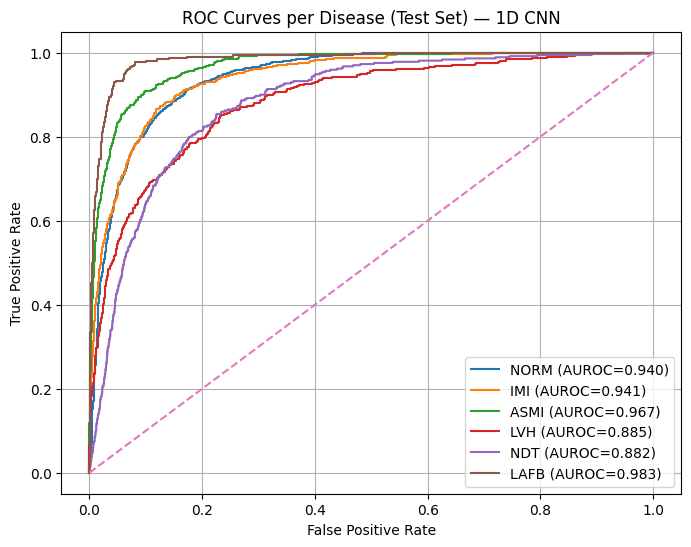

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))
for i, cls in enumerate(classes):
    y_true_c = te_y[:, i].astype(int)
    y_score_c = te_probs[:, i]

    if len(np.unique(y_true_c)) < 2:
        print(f"{cls}: ROC undefined (only one label present).")
        continue

    fpr, tpr, _ = roc_curve(y_true_c, y_score_c)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUROC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves per Disease (Test Set) — 1D CNN")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


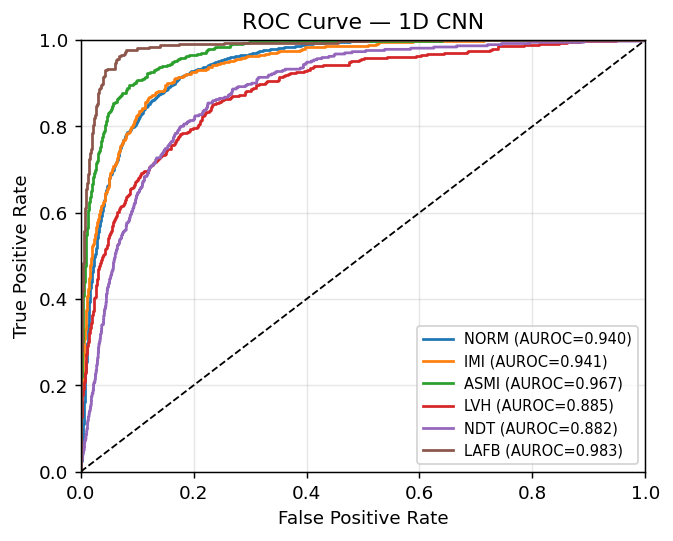

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(5.2, 4.2), dpi=132)  # match baseline size + higher resolution

ax = plt.gca()
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)

# IMPORTANT: remove padding that causes <0 and >1 space
ax.margins(x=0, y=0)

for i, cls in enumerate(classes):
    y_true_c = te_y[:, i].astype(int)
    y_score_c = te_probs[:, i]

    if len(np.unique(y_true_c)) < 2:
        print(f"{cls}: ROC undefined (only one label present).")
        continue

    fpr, tpr, _ = roc_curve(y_true_c, y_score_c)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=1.5, label=f"{cls} (AUROC={roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — 1D CNN")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# If you save for paper:
# plt.savefig("CNN_ROC.png", dpi=300, bbox_inches="tight")
